## Data Loading & Preprocessing

In [1]:
# Stage 1: Data Loading 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# Load dataset
df = pd.read_csv("star_classification.csv")

df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [3]:
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (100000, 18)
Rows: 100000
Columns: 18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [5]:
df.isnull().sum()
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Duplicate Rows: 0


In [6]:
df["class"].value_counts()
df["class"].value_counts(normalize=True) * 100

class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: proportion, dtype: float64

In [7]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


***Feature Selection***

In [8]:
columns_to_drop = [
    "obj_ID",
    "spec_obj_ID",
    "run_ID",
    "rerun_ID",
    "cam_col",
    "field_ID",
    "plate",
    "MJD",
    "fiber_ID"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

df.head(10)

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123
5,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,QSO,1.424659
6,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,QSO,0.586455
7,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,GALAXY,0.477009
8,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,GALAXY,0.660012
9,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,STAR,-0.000008


In [9]:
for col in ["u", "g", "r", "i", "z"]:
    print(col, (df[col] == -9999).sum())

u 1
g 1
r 0
i 0
z 1


In [10]:
df.replace(-9999, np.nan, inplace=True)
df.dropna(inplace=True)

In [48]:
print(df.isnull().sum())

print((df == -9999).sum())

alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64
alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64


In [49]:
df.describe()

,alpha,delta,u,g,r,i,z,redshift
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,177.628653,24.135552,22.080679,20.631583,19.645777,19.084865,18.768988,0.576667
std,96.502612,19.644608,2.251068,2.037384,1.854763,1.757900,1.765982,0.730709
min,0.005528,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971
25%,127.517698,5.147477,20.352410,18.965240,18.135795,17.732280,17.460830,0.054522
50%,180.900527,23.646462,22.179140,21.099930,20.125310,19.405150,19.004600,0.424176
75%,233.895005,39.901582,23.687480,22.123775,21.044790,20.396510,19.921120,0.704172
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


***Data Validation After Cleaning***

To verify the effectiveness of the preprocessing stage, the cleaned dataset was inspected for missing values and remaining invalid placeholder values (-9999). The results confirm that no missing or invalid values remain, indicating that the dataset is ready for feature engineering and model training.

***Prepare Features & Target***

In [11]:
X = df.drop("class", axis=1)
y = df["class"]

In [12]:
## Encode target
X = df.drop("class", axis=1)
y = df["class"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(encoder.classes_)

['GALAXY' 'QSO' 'STAR']


***Train & Test Split***

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

***Feature Scaling***

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (79999, 8)
Testing samples: (20000, 8)


## Exploratory Data Analysis (EDA)

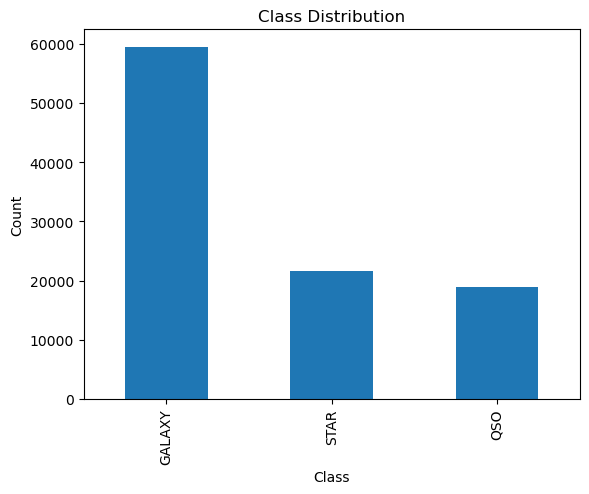

In [16]:
import matplotlib.pyplot as plt

df["class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

***Class Distribution Analysis:***

The dataset contains three astronomical object classes: galaxies, stars, and quasars (QSOs). Galaxies represent the majority of observations, accounting for approximately 59% of the dataset, while stars and quasars make up around 22% and 19%, respectively. Although the classes are not perfectly balanced, all three categories are sufficiently represented for supervised machine learning. This distribution suggests that stratified sampling should be used during train-test splitting to preserve the original class proportions and ensure reliable model evaluation.

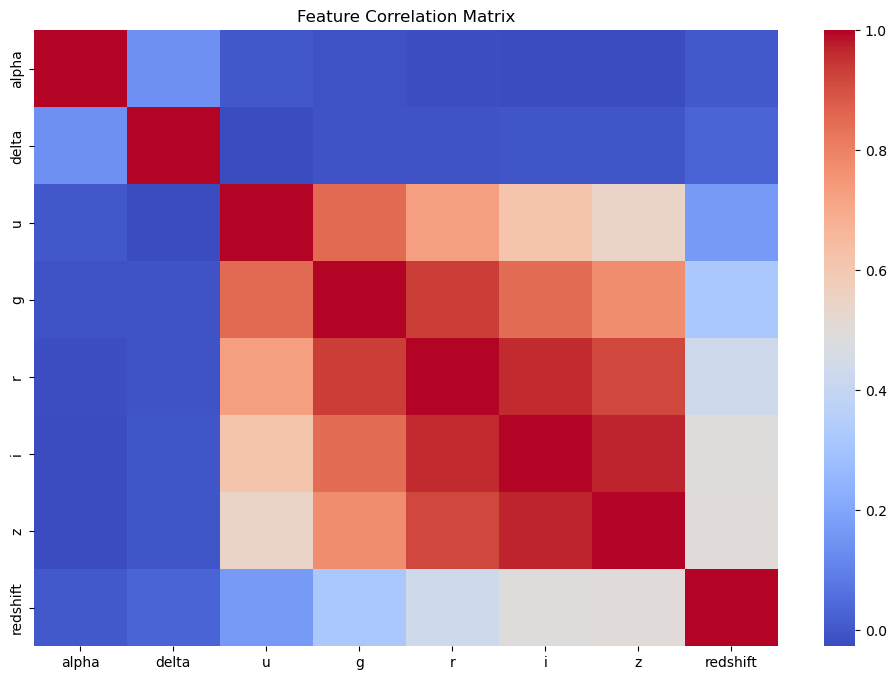

In [17]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("class", axis=1).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.show()

***Feature Correlation Matrix:***

The correlation heatmap illustrates the relationships between the numerical features after removing records containing invalid measurements. Strong positive correlations are observed among the photometric bands (u, g, r, i, and z), indicating that these filters capture related spectral information. Redshift shows moderate positive correlations with several photometric features, suggesting that objects at greater cosmological distances exhibit measurable changes in their observed spectra. Overall, the absence of extremely high correlations (excluding naturally related photometric bands) indicates that the dataset contains complementary rather than redundant information, making it well suited for machine learning classification.

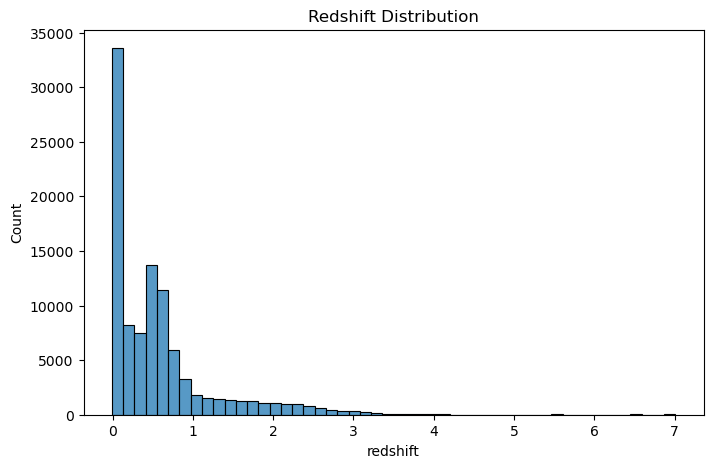

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["redshift"], bins=50)

plt.title("Redshift Distribution")
plt.show()

***Redshift Distribution Analysis:***

The histogram shows that the redshift feature is positively skewed, with most astronomical objects having relatively low redshift values and a gradually decreasing frequency as redshift increases. This pattern is expected in astronomical surveys because nearby objects are much more common than extremely distant ones. After removing records containing invalid measurements, the distribution appears smooth and realistic without artificial spikes, indicating that the preprocessing successfully eliminated erroneous values while preserving the natural characteristics of the data. The broad range of redshift values suggests that this feature contains valuable information for distinguishing between nearby stars, galaxies, and distant quasars.

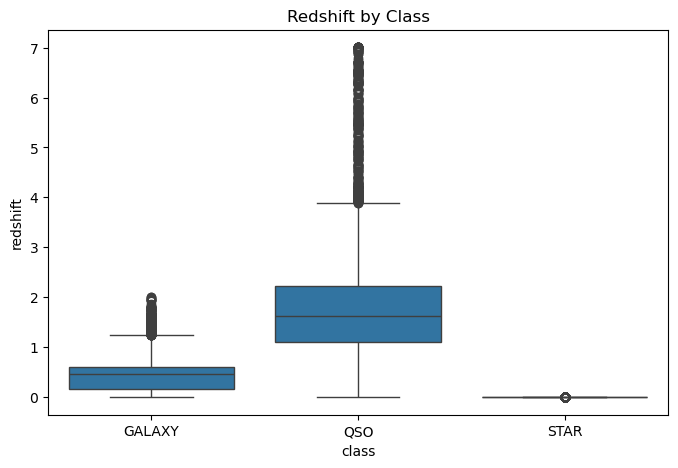

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="class",
    y="redshift",
    data=df
)

plt.title("Redshift by Class")
plt.show()

***Redshift by Class Analysis:***

The boxplot reveals clear differences in redshift distributions among the three astronomical object classes. Stars exhibit redshift values concentrated very close to zero with minimal variation, reflecting their location within the Milky Way. Galaxies display moderate redshift values and a wider distribution, indicating greater cosmological distances. Quasars (QSOs) have the highest median redshift and the greatest variability, with numerous high-value outliers representing extremely distant objects. After removing invalid measurements, the class separation becomes more distinct and accurately reflects the physical characteristics of these astronomical objects. This clear separation indicates that redshift is one of the most informative features for the classification task.

## Baseline Model (Logistic Regression)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [21]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [22]:
y_pred = log_model.predict(X_test_scaled)

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9584


In [24]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97     11889
         QSO       0.95      0.89      0.92      3792
        STAR       0.95      1.00      0.97      4319

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



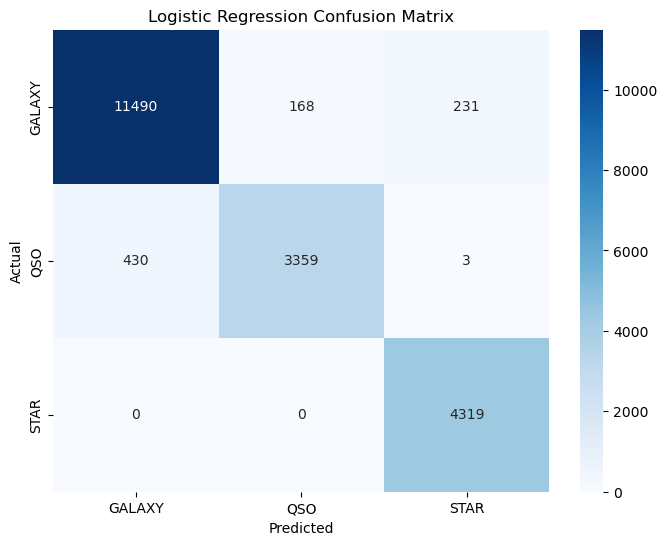

In [25]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

***Logistic Regression Performance:***

Logistic Regression achieved an overall accuracy of 95.84%, demonstrating that the dataset contains highly informative features. The model performed exceptionally well in identifying stars and galaxies, while quasars proved more challenging due to overlap with certain galaxy observations. The confusion matrix shows that most classification errors occur between galaxies and quasars, whereas stars are almost perfectly separated from the other classes. These results establish a strong baseline for comparison with more advanced machine learning models.

## Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [28]:
rf_pred = rf_model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.9798


In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



***Random Forest Performance:***

Random Forest was implemented as an ensemble learning model to improve upon the baseline Logistic Regression classifier. Unlike Logistic Regression, which assumes linear decision boundaries, Random Forest can capture complex non-linear relationships and interactions between features by combining the predictions of multiple decision trees. The model achieved an accuracy of 97.98%, outperforming the Logistic Regression baseline of 95.84%. This improvement indicates that the relationships between the astronomical features and object classes are not entirely linear and can be better captured by tree-based methods.

The strong performance of the Random Forest model demonstrates its ability to effectively distinguish between stars, galaxies, and quasars using the available photometric and spectroscopic features. By aggregating the predictions of many decision trees, the model reduces overfitting while maintaining high predictive accuracy. These results suggest that ensemble learning techniques are highly suitable for astronomical object classification and provide a strong benchmark for comparison with more advanced boosting methods such as XGBoost.

## XGBoost

In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

In [32]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [33]:
xgb_pred = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

XGBoost Accuracy: 0.9779


In [34]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.96      0.93      0.95      3792
        STAR       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



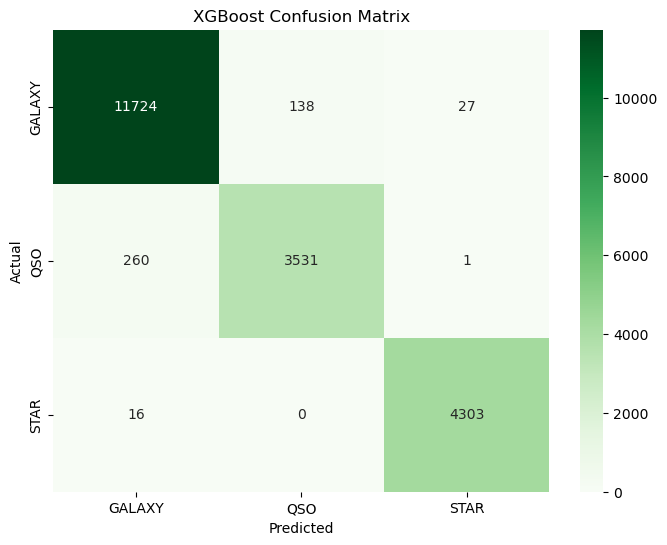

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [36]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,redshift,0.816748
3,g,0.074964
6,z,0.032323
2,u,0.028829
5,i,0.019684
4,r,0.012054
1,delta,0.008161
0,alpha,0.007237


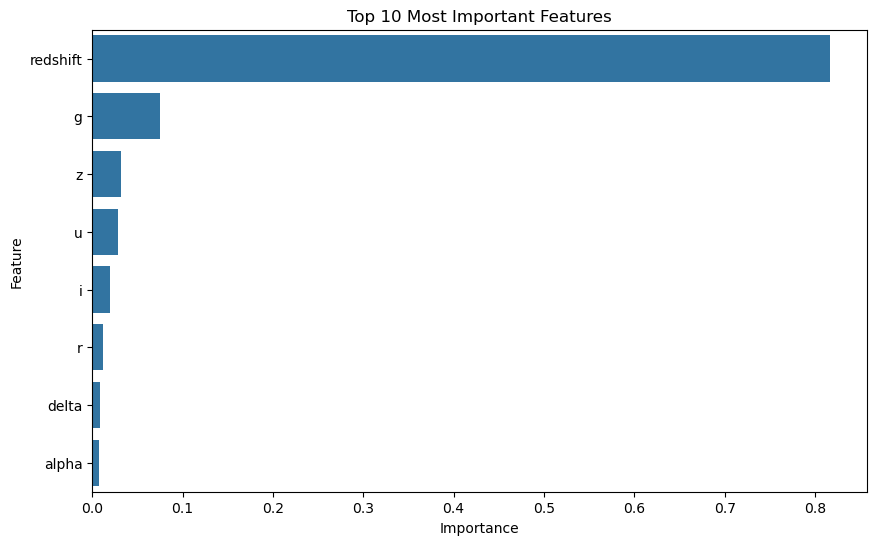

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.show()

***XGBoost Performance:***

XGBoost was implemented as a gradient boosting classifier to evaluate whether sequential tree boosting could outperform the Random Forest model on the cleaned SDSS dataset. Unlike Random Forest, which builds decision trees independently and combines their predictions, XGBoost constructs trees sequentially, with each new tree focusing on correcting errors made by previous trees. This boosting approach often produces highly accurate models for structured tabular data.

The XGBoost model achieved an overall accuracy of 97.79%, significantly outperforming the Logistic Regression baseline (95.84%) and demonstrating excellent predictive performance across all three astronomical object classes. The classification report shows precision, recall, and F1-scores above 0.93 for every class, indicating strong and balanced classification capability.

Analysis of the confusion matrix reveals that most objects were classified correctly, with only a small number of misclassifications occurring between galaxies and quasars. Stars remained the easiest class to identify, while the majority of classification errors involved quasars being confused with galaxies due to overlapping observational characteristics.

Although XGBoost delivered excellent results, it was slightly outperformed by the Random Forest model, which achieved a higher accuracy of 97.98% on the same cleaned dataset. This suggests that the additional complexity of gradient boosting provided only marginal benefits for this classification problem.

Overall, XGBoost proved to be a highly effective classifier for astronomical object classification; however, Random Forest emerged as the strongest-performing model in this study and was therefore selected as the preferred model prior to hyperparameter optimization.

## Model Comparison

In [38]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.9584,
        0.9798,
        0.9779
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.9584
1,Random Forest,0.9798
2,XGBoost,0.9779


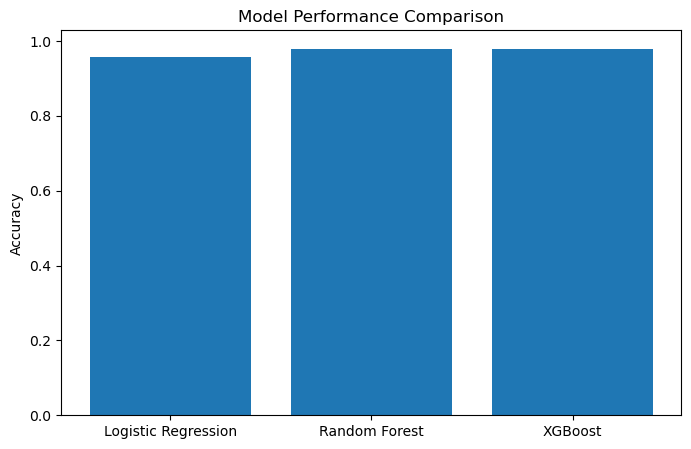

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")

plt.show()

## Hyperparameter Tuning

In [41]:
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(

    random_state=42

)

In [42]:
param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [10, 20, 30, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"],

    "bootstrap": [True, False]

}

In [43]:
random_search = RandomizedSearchCV(

    estimator=rf_base,

    param_distributions=param_grid,

    n_iter=20,

    cv=3,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy')

In [44]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}

Best CV Accuracy:
0.9781372234272107


In [45]:
best_rf = random_search.best_estimator_

tuned_rf_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

print(
    f"Tuned Random Forest Accuracy: "
    f"{tuned_rf_accuracy:.4f}"
)

Tuned Random Forest Accuracy: 0.9808


In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        tuned_rf_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



***Hyperparameter Tuning Results***

To further improve the best-performing model, hyperparameter tuning was applied to the Random Forest classifier using RandomizedSearchCV with cross-validation. Multiple combinations of model parameters, including the number of trees, tree depth, minimum samples per split, minimum samples per leaf, feature selection strategy, and bootstrap sampling, were evaluated to identify the optimal configuration.

The tuned Random Forest achieved a final accuracy of 98.08%, improving upon the default Random Forest accuracy of 97.98% while remaining the highest-performing model in this study. The classification report indicates consistently high precision, recall, and F1-scores across all three astronomical object classes. The slight improvement demonstrates that careful hyperparameter optimization can further enhance predictive performance, although the default model was already highly effective.

Overall, the tuned Random Forest produced the best balance between accuracy, robustness, and generalization, making it the final selected model for astronomical object classification.

In [47]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.9584,
        0.9798,
        0.9779,
        0.9808
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
3,Tuned Random Forest,0.9808
1,Random Forest,0.9798
2,XGBoost,0.9779
0,Logistic Regression,0.9584


### Limitations

Although the proposed model achieved high classification accuracy, several limitations remain. The model relies heavily on the redshift feature, which contributes most of the predictive power. Consequently, the classifier should be interpreted as combining both photometric and spectroscopic measurements rather than relying solely on imaging features. Future work could investigate model performance after excluding redshift, evaluate additional feature engineering techniques, and explore deep learning approaches on astronomical image datasets.

## Conclusion

This project investigated the classification of astronomical objects using the Sloan Digital Sky Survey (SDSS) dataset containing approximately 100,000 observations of stars, galaxies, and quasars. The workflow included data cleaning, preprocessing, exploratory data analysis (EDA), feature engineering, model development, evaluation, comparison, and hyperparameter tuning.

Exploratory Data Analysis showed that the dataset contained no duplicate records, while invalid -9999 values were identified and removed during preprocessing to improve data quality. The analysis also revealed a moderate class imbalance, with galaxies representing the largest class. Correlation analysis and feature importance evaluation demonstrated that the photometric measurements and redshift provide the strongest predictive information for distinguishing between astronomical object types.

Three machine learning models were evaluated: Logistic Regression, Random Forest, and XGBoost. Logistic Regression established a strong baseline with an accuracy of 95.84%. Ensemble learning methods significantly improved performance, with Random Forest achieving 97.98% accuracy and XGBoost achieving 97.79%, demonstrating the effectiveness of tree-based models for capturing the complex non-linear relationships within the dataset.

To obtain the best possible performance, Random Forest, which produced the highest accuracy among the baseline models, was further optimized using RandomizedSearchCV for hyperparameter tuning. The tuned Random Forest achieved a final accuracy of 98.08%, representing the highest performance obtained in this study. The optimized model also maintained consistently high precision, recall, and F1-scores across all three object classes, indicating excellent generalization performance.

Overall, the results demonstrate that machine learning techniques can accurately classify astronomical objects using photometric and spectroscopic measurements. Among all evaluated approaches, the Tuned Random Forest delivered the best overall performance, making it the most suitable model for this classification task. The study also highlights the importance of proper data preprocessing, feature engineering, model comparison, and hyperparameter optimization in developing accurate and reliable machine learning models for astronomical data analysis.